#### 1 Problem Understanding

-Analyze pharmaceutical sales

-Identify trends, top drugs, seasonality

#### 2 import dependencies and load dataset

In [65]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt 

In [40]:
#Load the dataset into my dataframe
path = 'C:\\Users\\kolad\\OneDrive\\Documents\\Data Science Project\\Analysing-pharmaceutical-sales-data\\data\\salesdaily.csv'
df = pd.read_csv(path)

In [9]:
# Display the first few rows to understand the structure of the dataset
df.head()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,1/3/2014,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,1/4/2014,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,1/5/2014,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,1/6/2014,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


#### 3. Data Understanding

shape, info, describe, columns

In [10]:
df.shape

(2106, 13)

In [11]:
#data statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
M01AB,2106.0,5.033683,2.737579,0.0,3.00,4.99,6.670,17.340000
M01AE,2106.0,3.895830,2.133337,0.0,2.34,3.67,5.138,14.463000
N02BA,2106.0,3.880441,2.384010,0.0,2.00,3.50,5.200,16.000000
N02BE,2106.0,29.917095,15.590966,0.0,19.00,26.90,38.300,161.000000
N05B,2106.0,8.853627,5.605605,0.0,5.00,8.00,12.000,54.833333
N05C,2106.0,0.593522,1.092988,0.0,0.00,0.00,1.000,9.000000
R03,2106.0,5.512262,6.428736,0.0,1.00,4.00,8.000,45.000000
R06,2106.0,2.900198,2.415816,0.0,1.00,2.00,4.000,15.000000
Year,2106.0,2016.401235,1.665060,2014.0,2015.00,2016.00,2018.000,2019.000000
Month,2106.0,6.344255,3.386954,1.0,3.00,6.00,9.000,12.000000


The sales daily dataset has 2106 rows and 13 columns

In [12]:
# datatype and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   datum         2106 non-null   object 
 1   M01AB         2106 non-null   float64
 2   M01AE         2106 non-null   float64
 3   N02BA         2106 non-null   float64
 4   N02BE         2106 non-null   float64
 5   N05B          2106 non-null   float64
 6   N05C          2106 non-null   float64
 7   R03           2106 non-null   float64
 8   R06           2106 non-null   float64
 9   Year          2106 non-null   int64  
 10  Month         2106 non-null   int64  
 11  Hour          2106 non-null   int64  
 12  Weekday Name  2106 non-null   object 
dtypes: float64(8), int64(3), object(2)
memory usage: 214.0+ KB


#### 4. Data Cleaning

In [13]:
# convert the date column to datetime format
df['datum'] = pd.to_datetime

#### 5. EDA
Let's explore the patterns in our data

In [14]:
df.columns

Index(['datum', 'M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03',
       'R06', 'Year', 'Month', 'Hour', 'Weekday Name'],
      dtype='object')

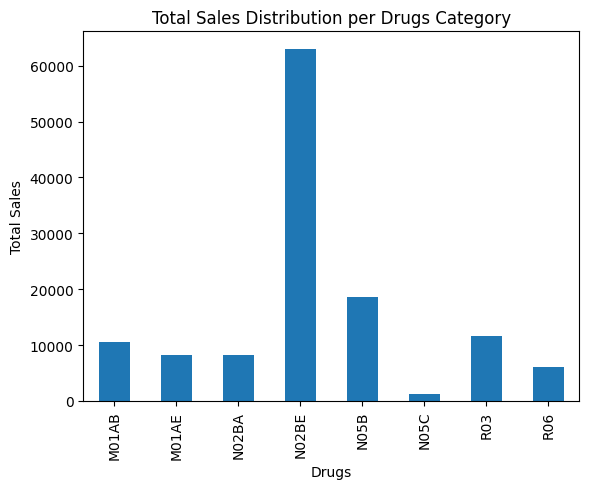

In [15]:
# Total sales distribution

drug_cols = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03',
       'R06']

df[drug_cols].sum().plot(kind='bar')
plt.title("Total Sales Distribution per Drugs Category")
plt.xlabel("Drugs")
plt.ylabel("Total Sales")

plt.show()

N02BE has the highest sales among the list of pharmaceuticals medication, followed by N05B

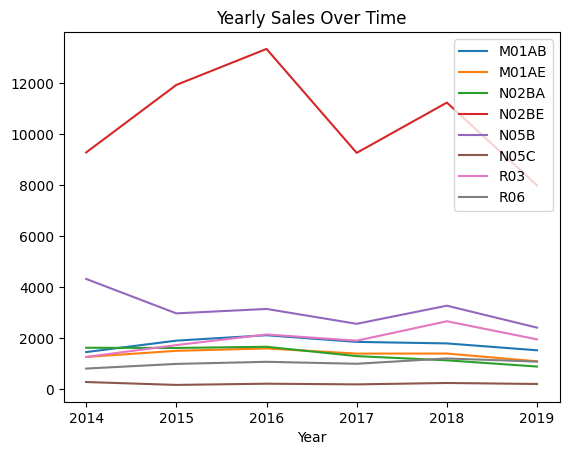

In [ ]:
# Year Sales over time

df.groupby('Year')[drug_cols].sum().plot(kind = 'line')
plt.title("Yearly Sales Over Time")

plt.show()

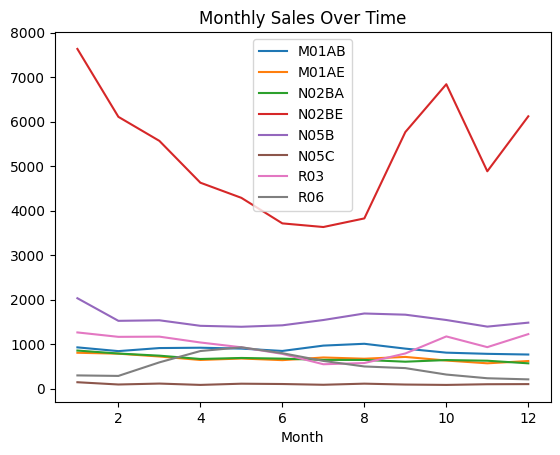

In [22]:
# Sales over time

df.groupby('Month')[drug_cols].sum().plot(kind = 'line')
plt.title("Monthly Sales Over Time")

plt.show()

#### 6. Business Questions to Answer


In [28]:
# Total sales Per Drug Category

total_sales = df[drug_cols].sum()
print(total_sales)

M01AB    10600.937083
M01AE     8204.618646
N02BA     8172.209000
N02BE    63005.402708
N05B     18645.737500
N05C      1249.958333
R03      11608.822917
R06       6107.817500
dtype: float64


In [45]:
# 2. Highest Selling drug
highest_selling_drug = total_sales.idxmax()
print(f"The highest selling drug category is: {highest_selling_drug}")

The highest selling drug category is: N02BE


In [43]:
highest_selling_drug_sales = total_sales.sort_values(ascending=False)
print(highest_selling_drug_sales)

N02BE    63005.402708
N05B     18645.737500
R03      11608.822917
M01AB    10600.937083
M01AE     8204.618646
N02BA     8172.209000
R06       6107.817500
N05C      1249.958333
dtype: float64


In [64]:
# Top 3 drugs with the highest sales in January 2015, July 2016, September 2017.

def top_3(year, month):
    data = df[(df['Month'] == month) & (df['Year'] == year)]
    totals = data[drug_cols].sum().sort_values(ascending=False).head(3)
    
    return pd.DataFrame({
        'Drug': totals.index,
        'Total Sales': totals.values,
        'Year': year,
        'Month': month
    })

# Combine all results
result = pd.concat([
    top_3(2015, 1),
    top_3(2016, 7),
    top_3(2017, 9)
])

result

,Drug,Total Sales,Year,Month
0,N02BE,1044.240000,2015,1
1,N05B,463.000000,2015,1
2,R03,177.250000,2015,1
0,N02BE,652.362000,2016,7
1,N05B,240.000000,2016,7
2,M01AB,194.528333,2016,7
0,N02BE,863.750000,2017,9
1,N05B,223.000000,2017,9
2,R03,139.000000,2017,9


In [58]:
# The most sold drugs in 2017

df[df['Year'] == 2017][drug_cols].sum().sort_values(ascending=False).idxmax()


'N02BE'

In [ ]:
# highest average sales per drug category
df[drug_cols].mean().sort_values(ascending=False)

N02BE    29.917095
N05B      8.853627
R03       5.512262
M01AB     5.033683
M01AE     3.895830
N02BA     3.880441
R06       2.900198
N05C      0.593522
dtype: float64

Text(0.5, 1.0, 'Monthly Sales of Respiratory Drugs (R03)')

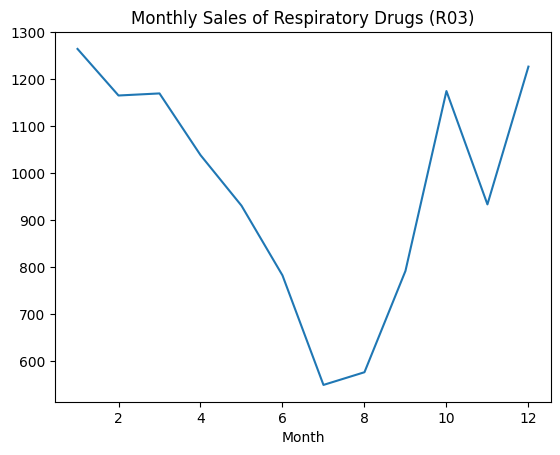

In [61]:
# Are respiratory drugs (R03) sold more during specific months?

df.groupby('Month')['R03'].sum().plot(kind='line')
plt.title("Monthly Sales of Respiratory Drugs (R03)")

#### 7. Insights & Conclusion


- Painkillers (N02BE) dominate overall sales

- Respiratory drugs (R03) peak in certain months (From December to February) → possible seasonal illness

- Some drugs show consistent daily demand → strong baseline products (N02BE - 29.917095,  N05B - 8.853627)
 